In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi Spark LENGKAP dengan Konfigurasi MinIO
spark = SparkSession.builder \
    .appName("ML_Turnover_CV") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

# 2. Load Data Gold
minio_path = "s3a://datalake/gold/employee-attrition"
gold_df = spark.read.parquet(minio_path)
print(f"✅ Data berhasil dimuat dari: {minio_path}")

✅ Data berhasil dimuat dari: s3a://datalake/gold/employee-attrition


In [2]:
# 1. Train-Test Split (80% Train, 20% Test)
train_split, test_split = gold_df.randomSplit([0.8, 0.2], seed=42)

print(f"⚙️ Data Training : {train_split.count():,} baris")
print(f"⚙️ Data Testing  : {test_split.count():,} baris")

⚙️ Data Training : 47,836 baris
⚙️ Data Testing  : 11,762 baris


In [3]:
# 1. Setup Model Dasar
rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)

# 2. Inisialisasi Evaluator
accuracy_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
precision_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# 3. Setup Parameter Grid (Mencari parameter terbaik)
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [20, 50])
             .addGrid(rf.maxDepth, [5, 8])
             .build())

# 4. Cross Validator
cv = CrossValidator(estimator=rf,
                    estimatorParamMaps=paramGrid,
                    evaluator=f1_eval, # Evaluasi berdasarkan F1 Score
                    numFolds=3)

print("⏳ Sedang melakukan proses Hyperparameter Tuning (Cross Validation)...")
# Latih Model CV
cv_model = cv.fit(train_split) 
best_model = cv_model.bestModel
print("✅ Tuning selesai! Model terbaik berhasil didapatkan.")

⏳ Sedang melakukan proses Hyperparameter Tuning (Cross Validation)...
✅ Tuning selesai! Model terbaik berhasil didapatkan.


In [4]:
# Prediksi menggunakan model terbaik
predictions = best_model.transform(test_split)

# Ekstrak nilai metrik
accuracy = accuracy_eval.evaluate(predictions)
f1 = f1_eval.evaluate(predictions)
precision = precision_eval.evaluate(predictions)
recall = recall_eval.evaluate(predictions)

print("--- 📊 HASIL EVALUASI MODEL TERBAIK ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

--- 📊 HASIL EVALUASI MODEL TERBAIK ---
Accuracy  : 0.7383
Precision : 0.7380
Recall    : 0.7383
F1 Score  : 0.7380


In [5]:
# Tarik nilai feature importance dari model terbaik
importance = best_model.featureImportances.toArray()

try:
    # Ekstrak nama kolom dari metadata Spark
    attrs = gold_df.schema["features"].metadata["ml_attr"]["attrs"]
    list_attrs = attrs.get("numeric", []) + attrs.get("binary", []) + attrs.get("nominal", [])
    feature_names = [x["name"] for x in sorted(list_attrs, key=lambda x: x["idx"])]
    
    # Buat DataFrame Pandas
    importance_df = pd.DataFrame(
        list(zip(feature_names, importance)), 
        columns=["Feature", "Importance"]
    ).sort_values(by="Importance", ascending=False)

    print("--- 🏆 TOP 10 FEATURE IMPORTANCE ---")
    print(importance_df.head(10))

    # Ekspor Feature Importance ke MinIO
    spark.createDataFrame(importance_df).write.mode("overwrite").parquet("s3a://datalake/gold/feature_importance/")
    print("\n✅ Data Feature Importance berhasil disimpan ke: s3a://datalake/gold/feature_importance/")

except Exception as e:
    print(f"⚠️ Error saat menarik nama kolom: {e}")

--- 🏆 TOP 10 FEATURE IMPORTANCE ---
                       Feature  Importance
34   Marital Status_ohe_Single    0.180425
38        Job Level_ohe_Senior    0.166654
36         Job Level_ohe_Entry    0.136210
42          Remote Work_ohe_No    0.083518
43         Remote Work_ohe_Yes    0.080242
33  Marital Status_ohe_Married    0.071575
37           Job Level_ohe_Mid    0.029706
3         Number of Promotions    0.027005
15  Work-Life Balance_ohe_Fair    0.025594
4           Distance from Home    0.020259

✅ Data Feature Importance berhasil disimpan ke: s3a://datalake/gold/feature_importance/


In [6]:
# 1. Ekspor Hasil Prediksi ke MinIO
predictions.select("label", "prediction").write.mode("overwrite").parquet("s3a://datalake/gold/predictions/")
print("✅ Data Prediksi berhasil disimpan ke: s3a://datalake/gold/predictions/")

# 2. Ekspor Hasil Evaluasi ke MinIO
evaluation_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Precision", "Recall"],
    "Value": [accuracy, f1, precision, recall]
})

spark.createDataFrame(evaluation_df).write.mode("overwrite").parquet("s3a://datalake/gold/model_evaluation/")
print("✅ Metrik Evaluasi berhasil disimpan ke: s3a://datalake/gold/model_evaluation/")

✅ Data Prediksi berhasil disimpan ke: s3a://datalake/gold/predictions/
✅ Metrik Evaluasi berhasil disimpan ke: s3a://datalake/gold/model_evaluation/


/tmp/ipykernel_5005/3282370623.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df.head(10), palette="Blues_r")


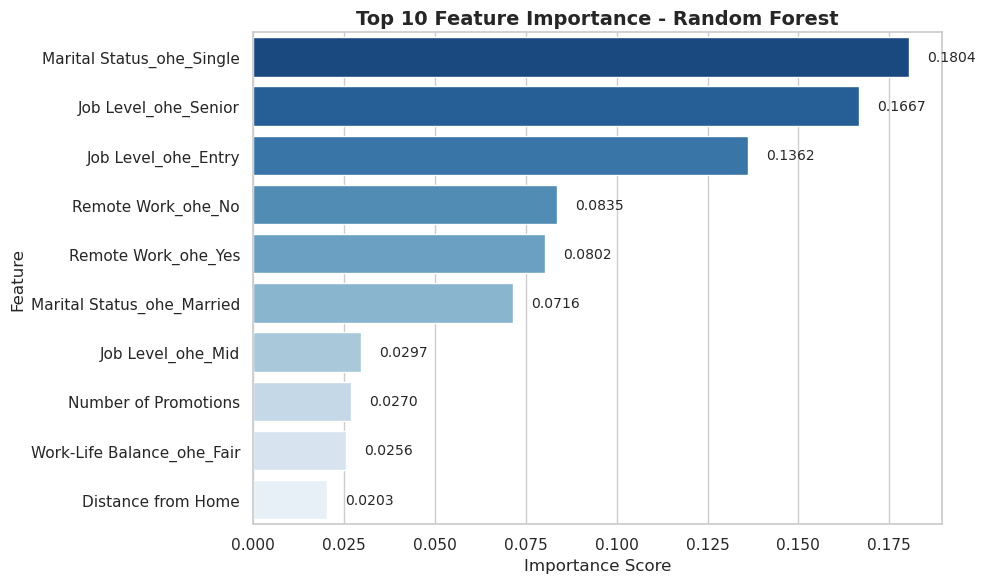

/tmp/ipykernel_5005/3282370623.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x="Metric", y="Value", data=evaluation_df, palette="viridis")


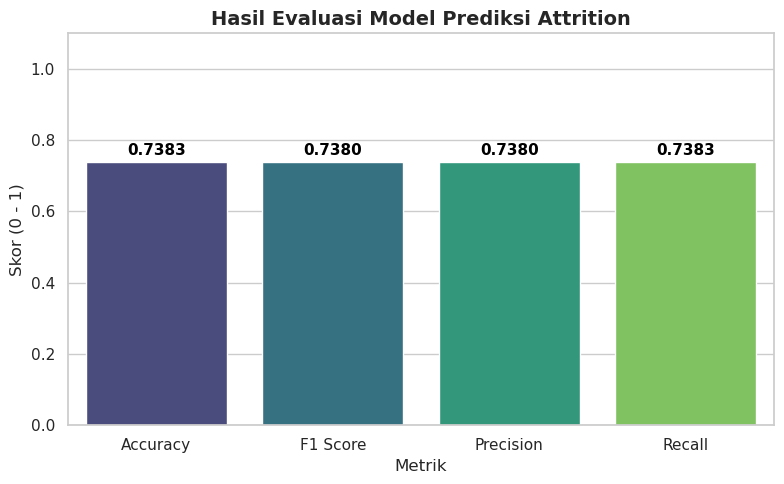

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi agar terlihat modern dan rapi
sns.set_theme(style="whitegrid")

# ==========================================
# 1. VISUALISASI TOP 10 FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(10, 6))
# Membuat bar chart, sumbu X adalah skor, sumbu Y adalah nama fitur
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10), palette="Blues_r")

plt.title("Top 10 Feature Importance - Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Menambahkan angka di sebelah kanan setiap batang
for index, value in enumerate(importance_df.head(10)["Importance"]):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# 2. VISUALISASI METRIK EVALUASI
# ==========================================
plt.figure(figsize=(8, 5))
# Membuat bar chart untuk Accuracy, Precision, Recall, dan F1-Score
bar_plot = sns.barplot(x="Metric", y="Value", data=evaluation_df, palette="viridis")

plt.title("Hasil Evaluasi Model Prediksi Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Metrik", fontsize=12)
plt.ylabel("Skor (0 - 1)", fontsize=12)
plt.ylim(0, 1.1) # Membatasi sumbu Y maksimal 1.1 agar ada ruang untuk teks

# Menambahkan angka persis di atas setiap batang
for index, row in evaluation_df.iterrows():
    plt.text(index, row.Value + 0.02, f'{row.Value:.4f}', color='black', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()